# Weather regimes and wind droughts during ENSO (1980–2020)

This notebook tests how the El Niño–Southern Oscillation (ENSO) modulates synoptic
weather types (SWTs) and wind droughts over Australia, with a focus on the southeast
(the core of the NEM wind fleet).

**ENSO definition used here.** Each event runs from **June of year 0 to May of year 1**,
so a day belongs to the ENSO year of the preceding June. La Niña and El Niño years are
provided as lists; every other ENSO year is treated as Neutral.

**What we look at**

1. How often each SWT occurs under La Niña, El Niño and Neutral conditions, and how that
   differs from the climatology (regime anomalies).
2. Whether wind droughts (CF < 0.10) are more or less frequent per grid cell and per
   season under each ENSO phase.
3. Which SWTs dominate the drought days in the southeast under each phase.

**Data**

- van der Wiel capacity factor (ERA5), daily 1980–2020.
- Australian Synoptic Weather Types (Barnes et al. 2025), one label per day.


## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore")

xr.set_options(keep_attrs=True)
print("xarray", xr.__version__)

xarray 2024.5.0


## 2. Configuration

The ENSO year lists below are the ones you provided. A "1983 La Niña" covers
June 1983 → May 1984. Edit the lists here if your classification changes.

In [2]:
# --- ENSO years (start year = June of year 0) ---
LANINA_YEARS = [1983, 1984, 1988, 1995, 1998, 1999, 2000, 2005,
                2007, 2008, 2010, 2011, 2016, 2017, 2020]
ELNINO_YEARS = [1982, 1986, 1987, 1991, 1992, 1994, 1997, 2002,
                2004, 2006, 2009, 2015, 2018]

# --- Drought threshold ---
CF_THRESHOLD = 0.10

# --- Map domain ---
LON_MIN, LON_MAX =  110, 155
LAT_MIN, LAT_MAX =  -45, -10

# --- Southeast box (NEM wind core) ---
LON_MIN_SE, LON_MAX_SE = 134, 153
LAT_MIN_SE, LAT_MAX_SE = -25, -39

# --- Period ---
YEAR_START, YEAR_END = 1980, 2020

# --- Paths ---
CF_DIR    = "/g/data/w42/dr6273/work/projects/Aus_energy/production_metrics/wind/capacity_factor/van_der_Wiel/"
SWTLIBDIR = "/g/data/gb02/mb0427/Australian_synoptic_weather_types/"
OUT_DIR   = "/g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/enso_analysis/"
os.makedirs(OUT_DIR, exist_ok=True)

# Reuse the cached daily CF from the dominant-SWT notebook if it exists
CF_CACHE = "/g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/dominant_swt/cf_daily_all_cache.nc"

SEASONS = {"DJF": [12,1,2], "MAM": [3,4,5], "JJA": [6,7,8], "SON": [9,10,11]}
PHASES  = ["La Nina", "El Nino", "Neutral"]
PHASE_COLORS = {"La Nina": "#2166ac", "El Nino": "#b2182b", "Neutral": "#888888"}

print(f"{len(LANINA_YEARS)} La Nina years, {len(ELNINO_YEARS)} El Nino years")

15 La Nina years, 13 El Nino years


## 3. Helper functions

In [3]:
def get_time_name(o):
    for c in ("time", "valid_time", "t"):
        if c in o.dims: return c
    raise KeyError("no time dim")

def get_lat_name(o):
    for c in ("latitude", "lat", "y"):
        if c in o.coords or c in o.dims: return c
    raise KeyError("no lat")

def get_lon_name(o):
    for c in ("longitude", "lon", "x"):
        if c in o.coords or c in o.dims: return c
    raise KeyError("no lon")

def subset_domain(da):
    laname, loname = get_lat_name(da), get_lon_name(da)
    lat = da[laname].values
    lat_slice = slice(LAT_MAX+0.5, LAT_MIN-0.5) if lat[0] > lat[-1] \
                else slice(LAT_MIN-0.5, LAT_MAX+0.5)
    return da.sel({loname: slice(LON_MIN-0.5, LON_MAX+0.5), laname: lat_slice})

def base_map(ax):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, alpha=0.05, zorder=0)
    ax.add_feature(cfeature.OCEAN, alpha=0.1, zorder=0)
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

def draw_se_box(ax):
    ax.plot([LON_MIN_SE, LON_MAX_SE, LON_MAX_SE, LON_MIN_SE, LON_MIN_SE],
            [LAT_MIN_SE, LAT_MIN_SE, LAT_MAX_SE, LAT_MAX_SE, LAT_MIN_SE],
            color="k", lw=1.5, transform=ccrs.PlateCarree())

## 4. SWT colours (Barnes et al. 2025)

In [4]:
SWT_COLORS = {
    "WH-A": "#8B0000", "WH-B": "#FF00FF", "WH-C": "#FF99FF", "WH-D": "#FFE5FF",
    "CH-A": "#FFD700", "CH-B": "#FFE680",
    "EH-A": "#8B1A1A", "EH-B": "#CD3333", "EH-C": "#E88080",
    "EH-D": "#F4AAAA", "EH-E": "#FFD0D0",
    "TH-A": "#8B4513", "TH-B": "#CD853F", "TH-C": "#FFDAB9",
    "FH-A": "#4CAF50", "FH-B": "#8BC34A", "FH-C": "#C5E1A5",
    "WCT-A": "#2B0DB5", "WCT-B": "#9B80E0",
    "COL-A": "#0D3B6E", "COL-B": "#1A7AAF", "COL-C": "#2196F3",
    "COL-D": "#64B5F6", "COL-E": "#90CAF9", "COL-F": "#C8E6FF",
    "AM-A":  "#004D40", "AM-B":  "#00695C", "AM-C":  "#00ACC1",
    "AM-D":  "#80CBC4", "AM-E":  "#E0F7F4",
}
print(f"{len(SWT_COLORS)} colours defined")

30 colours defined


## 5. Load SWT daily labels

In [5]:
ds_clim   = xr.open_dataset(f"{SWTLIBDIR}SWT_climatology/SWT_climatology.nc")
SWT_LIST  = list(ds_clim.SWTs.values)
N_SWT     = len(SWT_LIST)
SWT_INDEX = {name: i for i, name in enumerate(SWT_LIST)}

swt_time  = pd.DatetimeIndex(ds_clim.time.values)
swt_label = ds_clim["assigned_SWT"].values

mask_period = (swt_time >= pd.Timestamp(f"{YEAR_START}-01-01")) & \
              (swt_time <= pd.Timestamp(f"{YEAR_END}-12-31"))
swt_time  = swt_time[mask_period]
swt_label = swt_label[mask_period]

swt_by_date = {ts.date(): lbl for ts, lbl in zip(swt_time, swt_label)}
print(f"{len(SWT_LIST)} SWTs, {len(swt_by_date)} days of labels")

30 SWTs, 14975 days of labels


## 6. Load daily capacity factor (1980–2020)

In [6]:
if os.path.exists(CF_CACHE):
    print("Loading CF from cache...")
    cf_daily_all = xr.open_dataset(CF_CACHE)["cf"].load()
else:
    print("Building daily CF from van der Wiel files (this can take a while)...")
    cf_files = [
        f"{CF_DIR}wind_capacity_factor_van_der_Wiel_era5_hourly_{yr}_Aus.nc"
        for yr in range(YEAR_START, YEAR_END + 1)
        if os.path.exists(f"{CF_DIR}wind_capacity_factor_van_der_Wiel_era5_hourly_{yr}_Aus.nc")
    ]
    ds_all = xr.open_mfdataset(cf_files, combine="by_coords", chunks={"time": 24*30})
    cf_var = [v for v in ds_all.data_vars if ds_all[v].ndim >= 3][0]
    cf_all = subset_domain(ds_all[cf_var])
    tn = get_time_name(cf_all)
    cf_daily_all = cf_all.resample({tn: "1D"}).mean().astype("float32").load()
    os.makedirs(os.path.dirname(CF_CACHE), exist_ok=True)
    cf_daily_all.rename("cf").to_netcdf(CF_CACHE)
    print("Cache saved.")

tname_all    = get_time_name(cf_daily_all)
lat_name_all = get_lat_name(cf_daily_all)
lon_name_all = get_lon_name(cf_daily_all)
cf_lat_all   = cf_daily_all[lat_name_all].values
cf_lon_all   = cf_daily_all[lon_name_all].values
time_cf      = pd.DatetimeIndex(cf_daily_all[tname_all].values)
print("CF daily shape:", cf_daily_all.shape)

Loading CF from cache...
CF daily shape: (14976, 141, 181)


## 7. Assign an ENSO phase to every day

An ENSO year runs June(0) → May(1), so the ENSO year of a date is its calendar year if
the month is June or later, otherwise the previous year. We then label each ENSO year as
La Niña, El Niño or Neutral.

In [7]:
def enso_year_of(ts):
    """ENSO year = calendar year if month >= 6, else previous year."""
    return ts.year if ts.month >= 6 else ts.year - 1

def enso_phase_of(ts):
    ey = enso_year_of(ts)
    if ey in LANINA_YEARS: return "La Nina"
    if ey in ELNINO_YEARS: return "El Nino"
    return "Neutral"

# Phase array aligned with the CF time axis
phase_cf = np.array([enso_phase_of(ts) for ts in time_cf])
month_cf = time_cf.month

# Quick sanity check: number of days per phase
for ph in PHASES:
    n = (phase_cf == ph).sum()
    print(f"{ph:8s}: {n:6d} days ({n/len(phase_cf)*100:4.1f}%)")

La Nina :   5329 days (35.6%)
El Nino :   4748 days (31.7%)
Neutral :   4899 days (32.7%)


## 8. SWT frequency by ENSO phase

First a domain-wide view: how often each weather type occurs under each phase. Because
each day has exactly one SWT, this is a simple frequency distribution per phase.

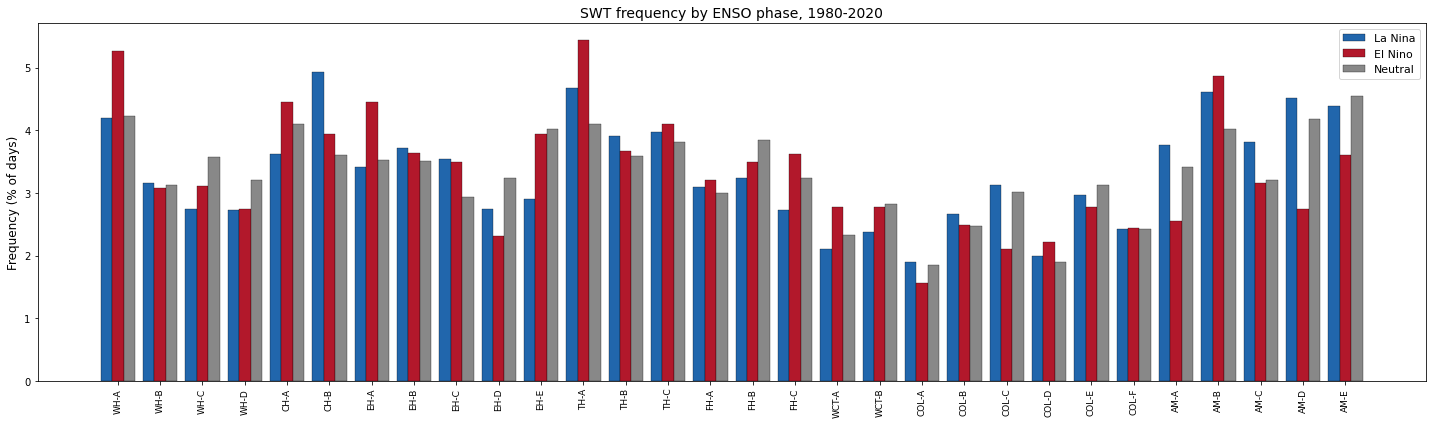

In [8]:
# SWT label per CF day (aligned by date)
swt_cf = np.array([swt_by_date.get(d.date(), None) for d in time_cf], dtype=object)

freq_by_phase = {}
for ph in PHASES:
    sub = swt_cf[(phase_cf == ph) & (swt_cf != None)]
    counts = pd.Series(sub).value_counts()
    freq = (counts / counts.sum() * 100).reindex(SWT_LIST).fillna(0)
    freq_by_phase[ph] = freq

# Grouped bar chart
x = np.arange(N_SWT)
w = 0.27
fig, ax = plt.subplots(figsize=(20, 6))
for i, ph in enumerate(PHASES):
    ax.bar(x + (i-1)*w, freq_by_phase[ph].values, w,
           label=ph, color=PHASE_COLORS[ph], edgecolor="k", lw=0.3)
ax.set_xticks(x)
ax.set_xticklabels(SWT_LIST, rotation=90, fontsize=9)
ax.set_ylabel("Frequency (% of days)", fontsize=12)
ax.set_title(f"SWT frequency by ENSO phase, {YEAR_START}-{YEAR_END}", fontsize=14)
ax.legend(fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "swt_frequency_by_phase.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9. SWT frequency anomaly during ENSO

More informative than raw frequency: how much each phase shifts the regime distribution
relative to the full-period climatology. Positive bars mean a regime is more common than
usual under that phase.

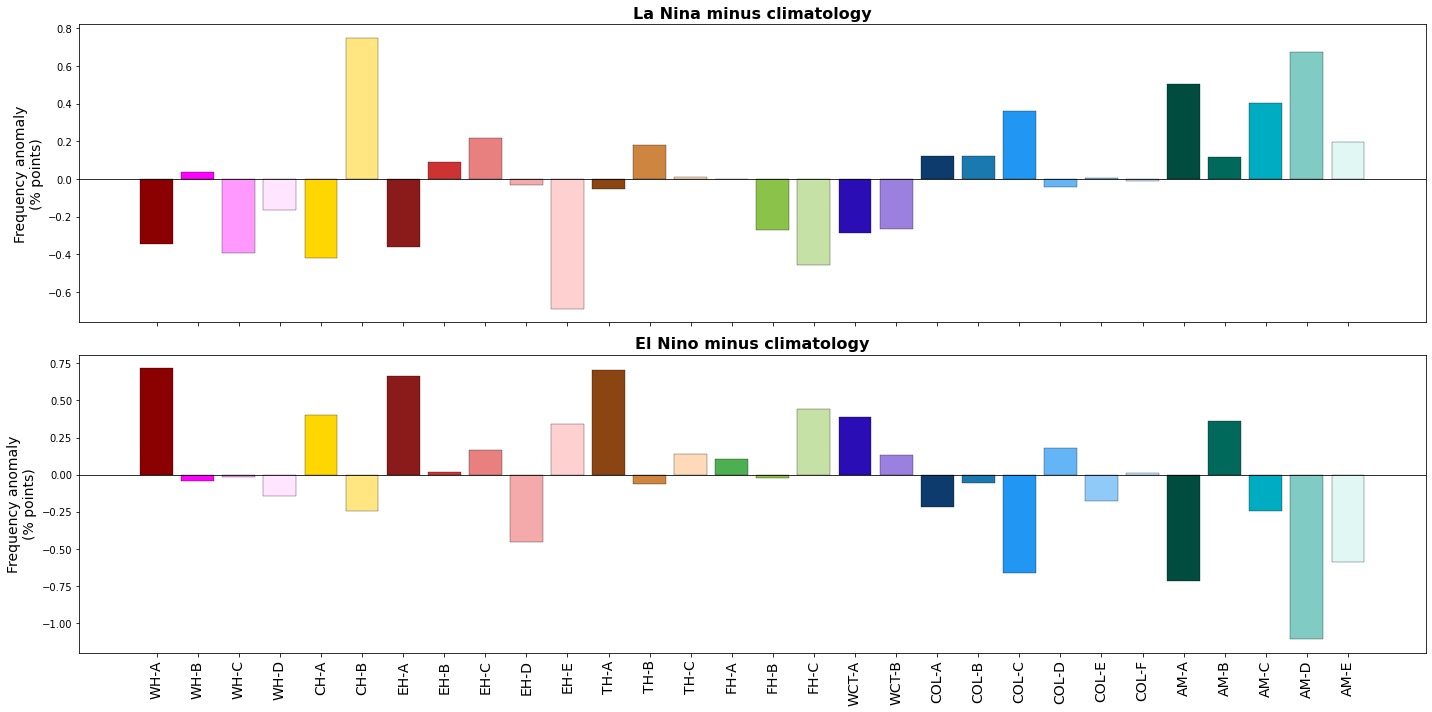

In [9]:
# Climatological frequency (all days)
sub_all = swt_cf[swt_cf != None]
clim_freq = (pd.Series(sub_all).value_counts() / len(sub_all) * 100).reindex(SWT_LIST).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
for ax, ph in zip(axes, ["La Nina", "El Nino"]):
    anom = freq_by_phase[ph] - clim_freq
    colors = [SWT_COLORS[s] for s in SWT_LIST]
    ax.bar(x, anom.values, color=colors, edgecolor="k", lw=0.3)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("Frequency anomaly\n(% points)", fontsize=14)
    ax.set_title(f"{ph} minus climatology", fontsize=16, fontweight="bold")

axes[1].set_xticks(x)
axes[1].set_xticklabels(SWT_LIST, rotation=90, fontsize=14)
fig.suptitle(f"SWT frequency anomaly during ENSO phases, {YEAR_START}-{YEAR_END}",
             fontsize=15, y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "swt_frequency_anomaly.png"), dpi=150, bbox_inches="tight")
plt.show()

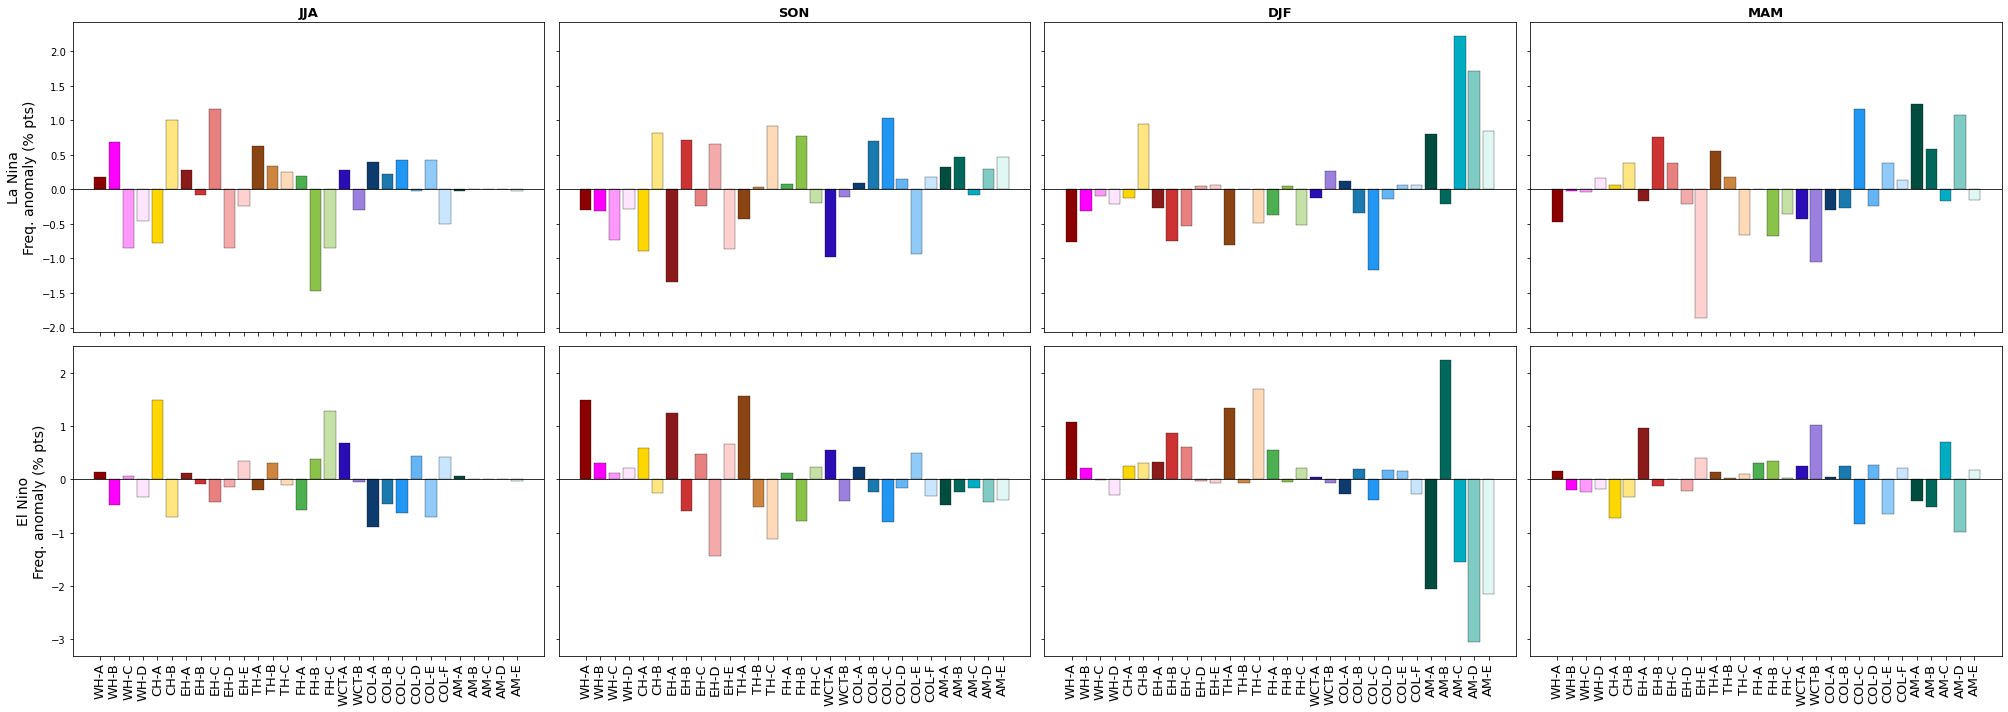

In [19]:
season_order = ["JJA", "SON", "DJF", "MAM"]
phases_plot  = ["La Nina", "El Nino"]

fig, axes = plt.subplots(len(phases_plot), len(season_order),
                         figsize=(28, 10), sharex=True, sharey="row")

for col, season in enumerate(season_order):
    months = SEASONS[season]
    season_mask = np.isin(month_cf, months)

    # Seasonal climatology
    sub_clim = swt_cf[season_mask & (swt_cf != None)]
    clim_s = (pd.Series(sub_clim).value_counts() / len(sub_clim) * 100
              ).reindex(SWT_LIST).fillna(0)

    # Seasonal frequency per phase
    for row, ph in enumerate(phases_plot):
        ax = axes[row, col]
        sub_ph = swt_cf[(phase_cf == ph) & season_mask & (swt_cf != None)]
        freq_s = (pd.Series(sub_ph).value_counts() / len(sub_ph) * 100
                  ).reindex(SWT_LIST).fillna(0)
        anom = freq_s - clim_s

        colors = [SWT_COLORS[s] for s in SWT_LIST]
        ax.bar(x, anom.values, color=colors, edgecolor="k", lw=0.3)
        ax.axhline(0, color="k", lw=0.8)

        # Column header (season) on first row only
        if row == 0:
            ax.set_title(season, fontsize=13, fontweight="bold")

        # Row label (phase) on first column only
        if col == 0:
            ax.set_ylabel(f"{ph}\nFreq. anomaly (% pts)", fontsize=14)

        # x labels on last row only
        if row == len(phases_plot) - 1:
            ax.set_xticks(x)
            ax.set_xticklabels(SWT_LIST, rotation=90, fontsize=13)

fig.suptitle(
    f"Seasonal SWT frequency anomaly (phase − climatology), {YEAR_START}-{YEAR_END}",
    fontsize=16, y=1.02,
)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "swt_frequency_anomaly_seasonal.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 10. Wind drought frequency per grid cell by ENSO phase

For every grid cell, the percentage of days in drought (CF < 0.10) under each phase.
A common colour scale lets you compare the three maps directly.

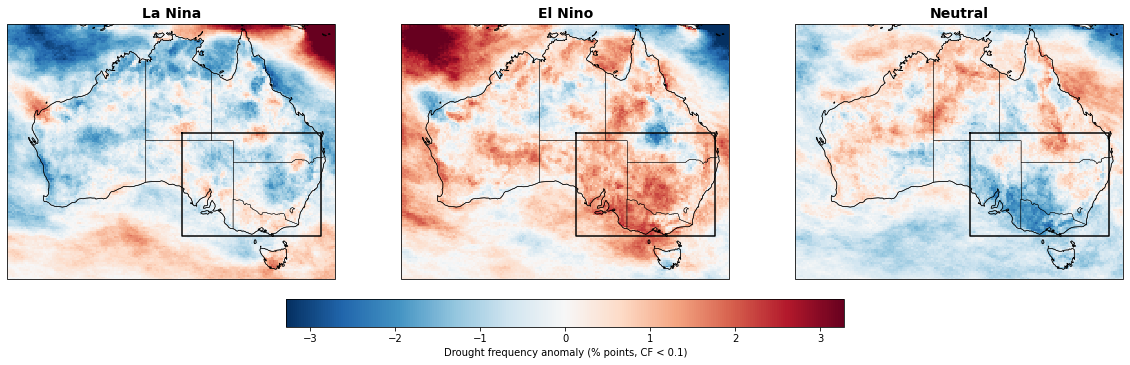

In [11]:
cf_vals = cf_daily_all.values

def drought_freq_map(day_mask):
    sub = cf_vals[day_mask]
    if sub.shape[0] == 0:
        return np.full(cf_vals.shape[1:], np.nan)
    return (sub < CF_THRESHOLD).mean(axis=0) * 100

# Climatology (all days)
clim_map = drought_freq_map(np.ones(len(phase_cf), dtype=bool))
valid = np.isfinite(cf_vals).any(axis=0)
clim_map = np.where(valid, clim_map, np.nan)

# Anomaly maps
anom_maps = {}
for ph in PHASES:
    raw = drought_freq_map(phase_cf == ph)
    raw = np.where(valid, raw, np.nan)
    anom_maps[ph] = raw - clim_map

vlim = np.nanpercentile(np.abs(np.stack(list(anom_maps.values()))), 99)

fig, axes = plt.subplots(1, 3, figsize=(20, 6),
                         subplot_kw={"projection": ccrs.PlateCarree()})
for ax, ph in zip(axes, PHASES):
    base_map(ax)
    draw_se_box(ax)
    pm = ax.pcolormesh(cf_lon_all, cf_lat_all, anom_maps[ph],
                       cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                       transform=ccrs.PlateCarree(), shading="auto")
    ax.set_title(ph, fontsize=14, fontweight="bold")

cb = fig.colorbar(pm, ax=axes, orientation="horizontal", shrink=0.5, pad=0.06)
cb.set_label(f"Drought frequency anomaly (% points, CF < {CF_THRESHOLD})")
fig.suptitle(
    f"Wind drought frequency anomaly vs climatology by ENSO phase\n{YEAR_START}-{YEAR_END}",
    fontsize=15, y=1.04,
)
fig.savefig(os.path.join(OUT_DIR, "drought_freq_anomaly_by_phase.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [12]:
import urllib.request

# Download WRI Global Power Plant Database (CC BY 4.0)
GPPD_URL  = "https://raw.githubusercontent.com/wri/global-power-plant-database/master/output_database/global_power_plant_database.csv"
GPPD_PATH = os.path.join(OUT_DIR, "global_power_plant_database.csv")

if not os.path.exists(GPPD_PATH):
    print("Downloading Global Power Plant Database...")
    urllib.request.urlretrieve(GPPD_URL, GPPD_PATH)
    print("Done.")

gppd = pd.read_csv(GPPD_PATH)
wind_aus = gppd[(gppd["country"] == "AUS") & (gppd["primary_fuel"] == "Wind")].copy()
print(f"{len(wind_aus)} Australian wind farms found")
print(wind_aus[["name", "capacity_mw", "latitude", "longitude"]].head(10))

65 Australian wind farms found
                                  name  capacity_mw  latitude  longitude
337                   Albany Wind Farm         21.6  -35.0641   117.7977
343                   Ararat Wind Farm        240.0  -37.2385   143.0794
363                  Blayney Wind Farm          9.9  -33.6219   149.1982
366  Bluff Point (Woolnorth) Wind Farm         65.0  -40.7207   144.6869
367                          Boco Rock        113.0  -36.5763   149.1267
368                Bodangora Wind Farm        113.0  -32.4146   149.0998
398                  Canunda Wind Farm         46.0  -37.7603   140.4033
399         Cape Bridgewater Wind Farm         58.0  -38.3577   141.3850
401        Cape Nelson North Wind Farm         22.0  -38.3676   141.5430
402        Cape Nelson South Wind Farm         44.0  -38.4120   141.5430


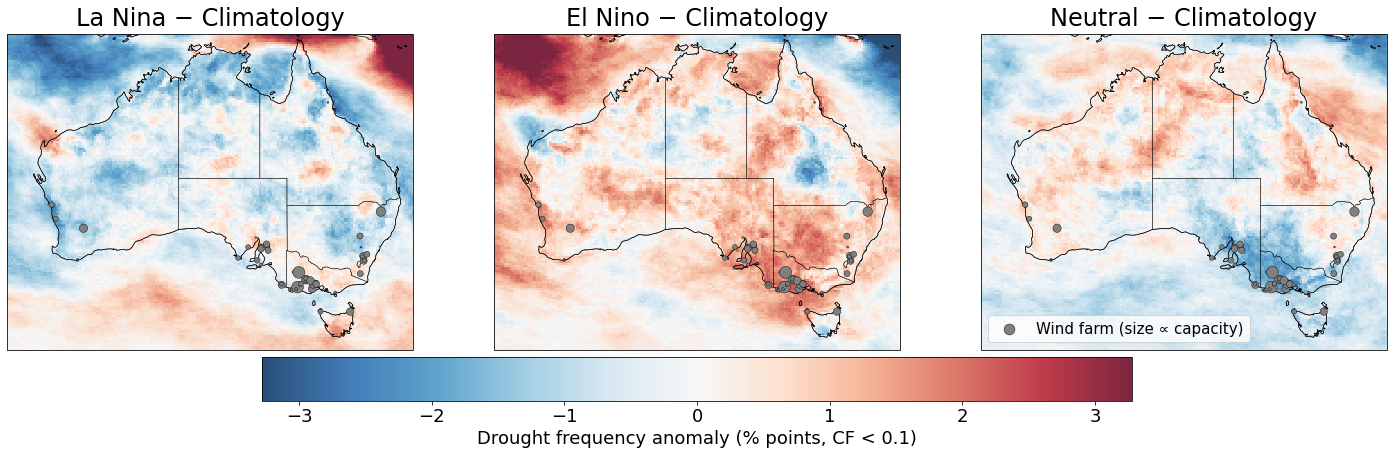

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(26, 7),
                         subplot_kw={"projection": ccrs.PlateCarree()})
fig.subplots_adjust(wspace=0.02)

for ax, ph in zip(axes, PHASES):
    base_map(ax)
    pm = ax.pcolormesh(cf_lon_all, cf_lat_all, anom_maps[ph],
                       cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                       transform=ccrs.PlateCarree(), shading="auto",
                       alpha=0.85)
    ax.scatter(
        wind_aus["longitude"], wind_aus["latitude"],
        s=wind_aus["capacity_mw"] / 3,
        c="lightgrey", edgecolors="k", lw=0.4, zorder=5,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(f"{ph} − Climatology", fontsize=24, pad=8)

cb = fig.colorbar(pm, ax=axes, orientation="horizontal",
                  shrink=0.6, pad=0.04)
cb.set_label(
    f"Drought frequency anomaly (% points, CF < {CF_THRESHOLD})",
    fontsize=18,
)
cb.ax.tick_params(labelsize=18)

axes[-1].scatter([], [], s=120, c="grey", edgecolors="k", lw=0.4,
                 label="Wind farm (size ∝ capacity)")
axes[-1].legend(loc="lower left", fontsize=15, frameon=True)

fig.suptitle(
    f"Wind drought frequency anomaly vs climatology by ENSO phase\n"
    f"Australian wind farm locations overlaid  |  {YEAR_START}-{YEAR_END}",
    fontsize=22, y=1.04,
)
fig.savefig(os.path.join(OUT_DIR, "drought_anomaly_windfarms_3panels.png"),
            dpi=150, bbox_inches="tight", pad_inches=0.3)
plt.show()

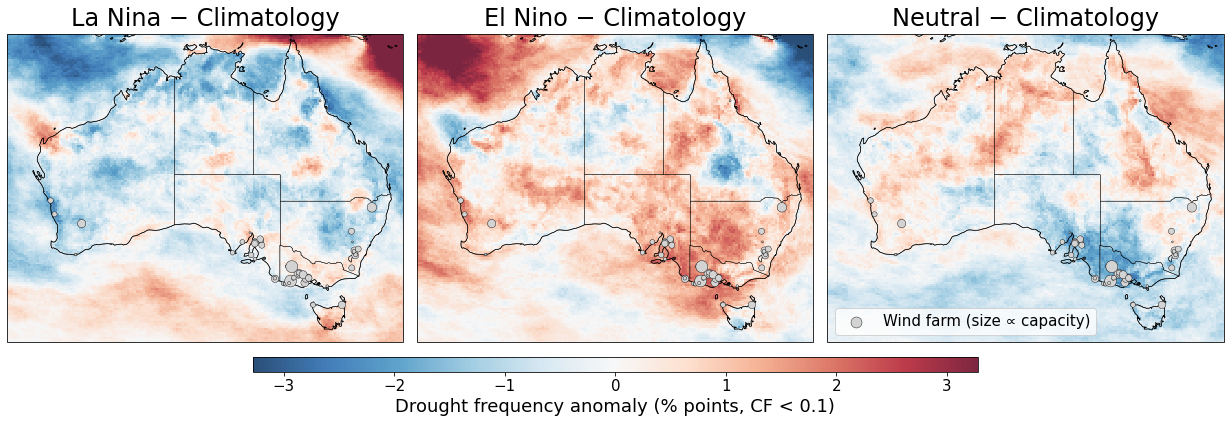

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(26, 7),
                         subplot_kw={"projection": ccrs.PlateCarree()})
fig.subplots_adjust(wspace=-0.35)

for ax, ph in zip(axes, PHASES):
    base_map(ax)
    pm = ax.pcolormesh(cf_lon_all, cf_lat_all, anom_maps[ph],
                       cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                       transform=ccrs.PlateCarree(), shading="auto",
                       alpha=0.85)
    ax.scatter(
        wind_aus["longitude"], wind_aus["latitude"],
        s=wind_aus["capacity_mw"] / 3,
        c="lightgrey", edgecolors="k", lw=0.4, zorder=5,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(f"{ph} − Climatology", fontsize=24, pad=8)

cb = fig.colorbar(pm, ax=axes, orientation="horizontal",
                  shrink=0.5, pad=0.04, aspect=50)
cb.set_label(
    f"Drought frequency anomaly (% points, CF < {CF_THRESHOLD})",
    fontsize=18,
)
cb.ax.tick_params(labelsize=15)

axes[-1].scatter([], [], s=120, c="lightgrey", edgecolors="k", lw=0.4,
                 label="Wind farm (size ∝ capacity)")
axes[-1].legend(loc="lower left", fontsize=15, frameon=True)

fig.suptitle(
    f"Wind drought frequency anomaly vs climatology by ENSO phase\n"
    f"Australian wind farm locations overlaid  |  {YEAR_START}-{YEAR_END}",
    fontsize=22, y=1.04,
)
fig.savefig(os.path.join(OUT_DIR, "drought_anomaly_windfarms_3panels.png"),
            dpi=150, bbox_inches="tight", pad_inches=0.3)
plt.show()

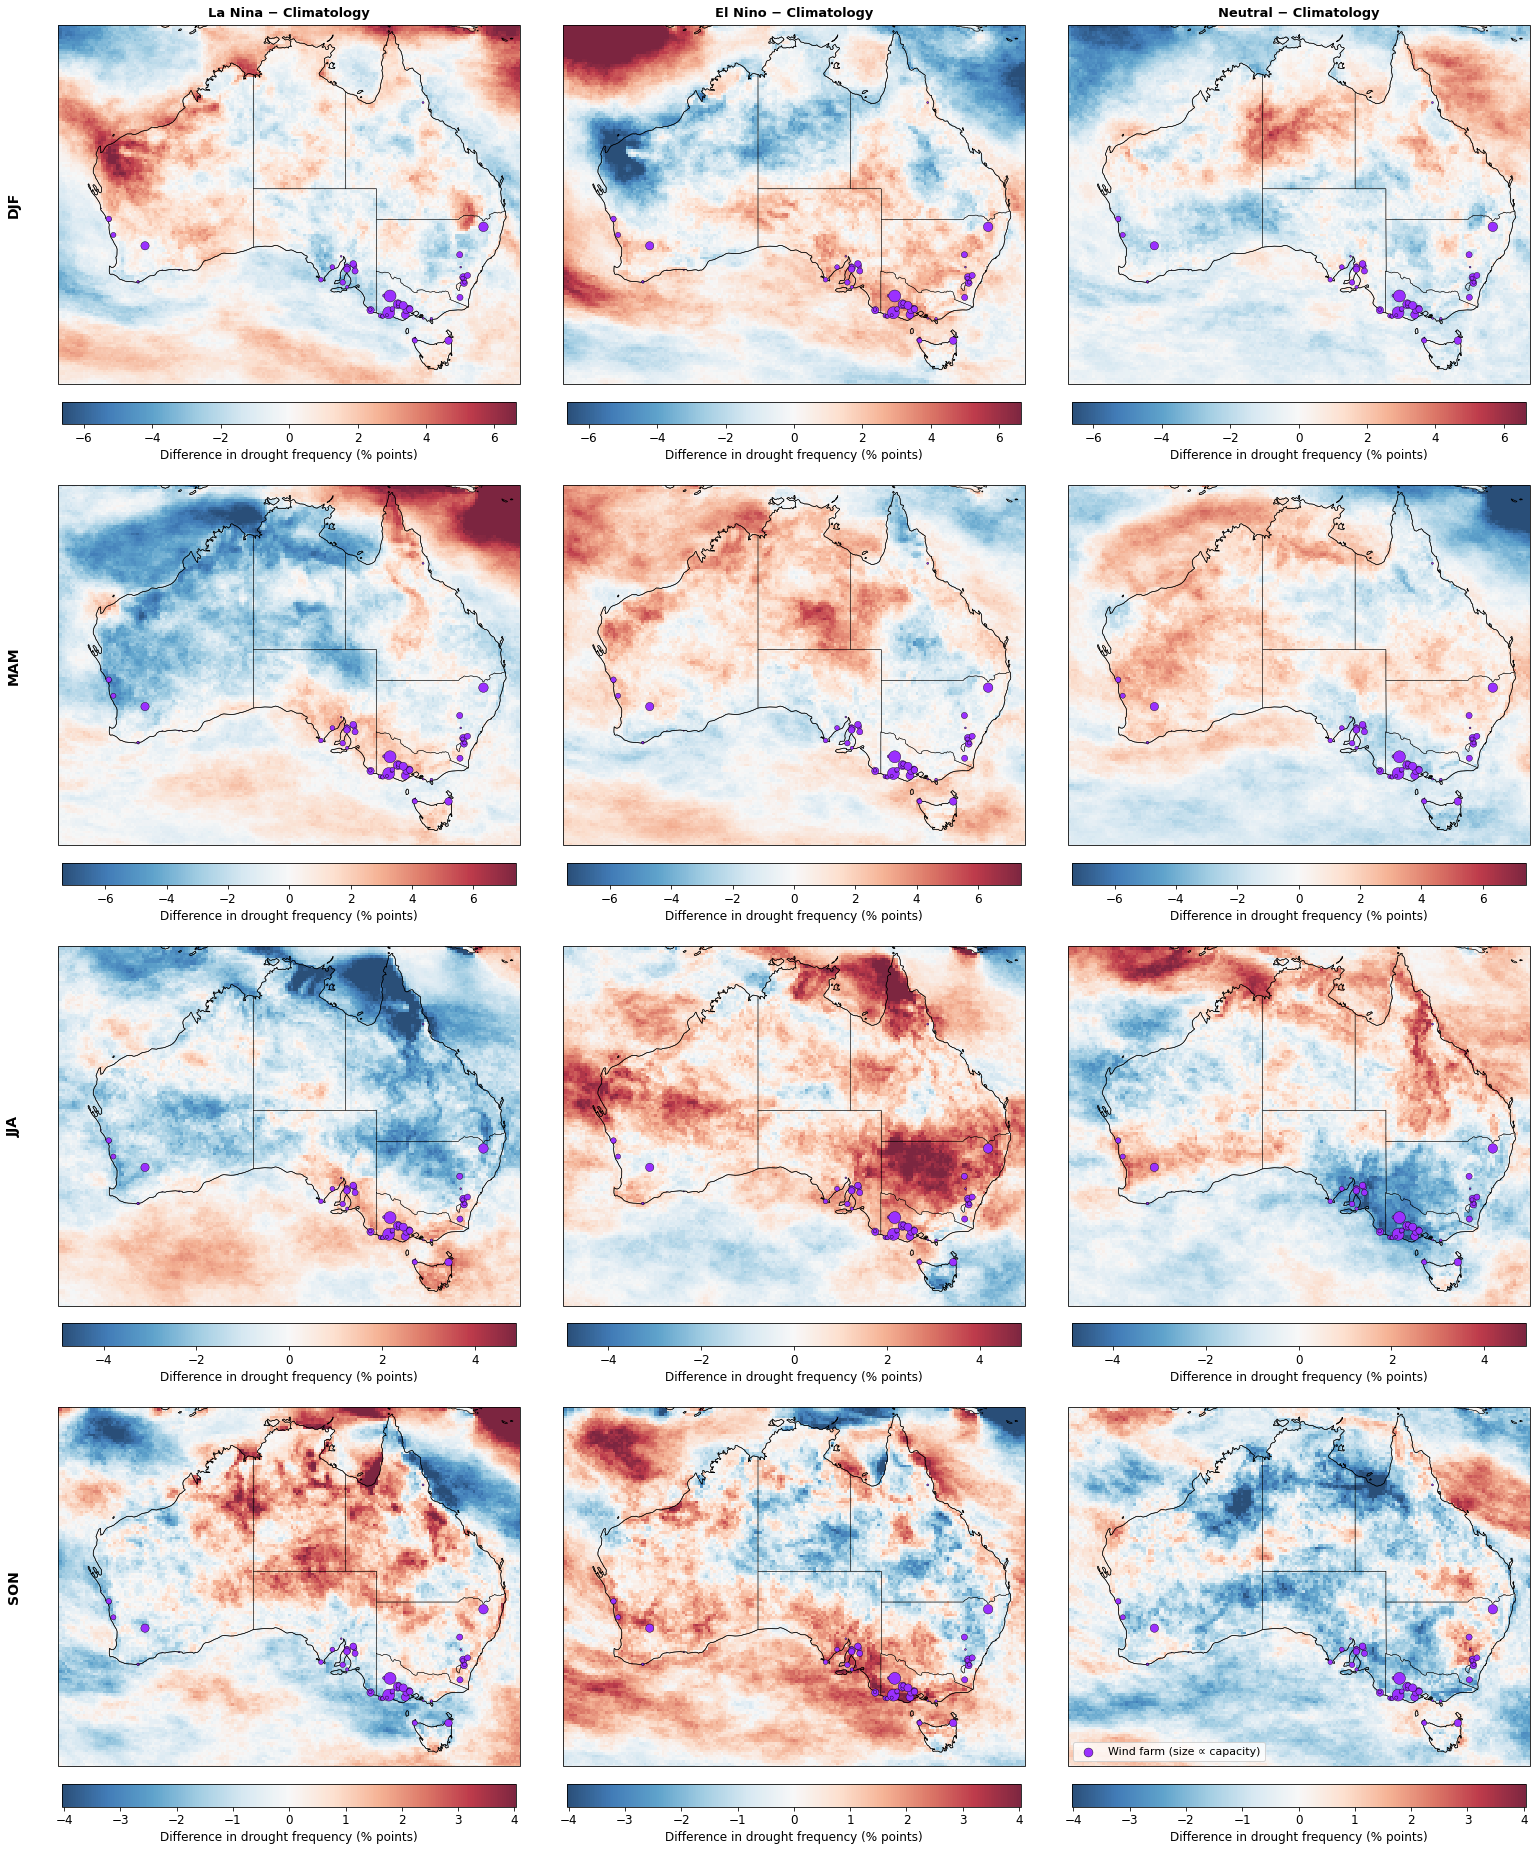

In [25]:
fig, axes = plt.subplots(4, 3, figsize=(22, 26),
                         subplot_kw={"projection": ccrs.PlateCarree()})

# Compute seasonal anomaly maps for each phase
season_order = ["DJF", "MAM", "JJA", "SON"]

for row, season in enumerate(season_order):
    months = SEASONS[season]

    # Climatology for this season
    clim_season = drought_freq_map(np.isin(month_cf, months))
    clim_season = np.where(valid, clim_season, np.nan)

    # Phase anomaly maps for this season
    anom_season = {}
    for ph in PHASES:
        raw = drought_freq_map((phase_cf == ph) & np.isin(month_cf, months))
        raw = np.where(valid, raw, np.nan)
        anom_season[ph] = raw - clim_season

    vlim_s = np.nanpercentile(
        np.abs(np.stack([anom_season[ph] for ph in PHASES])), 99
    )

    for col, ph in enumerate(PHASES):
        ax = axes[row, col]
        base_map(ax)

        pm = ax.pcolormesh(cf_lon_all, cf_lat_all, anom_season[ph],
                           cmap="RdBu_r", vmin=-vlim_s, vmax=vlim_s,
                           transform=ccrs.PlateCarree(), shading="auto",
                           alpha=0.85)

        ax.scatter(
            wind_aus["longitude"], wind_aus["latitude"],
            s=wind_aus["capacity_mw"] / 3,
            c="#9B30FF", edgecolors="k", lw=0.4, zorder=5,
            transform=ccrs.PlateCarree(),
        )

        # Column header (phase) only on first row
        if row == 0:
            ax.set_title(f"{ph} − Climatology", fontsize=13, fontweight="bold", pad=8)

        # Row label (season) only on first column
        if col == 0:
            ax.text(-0.08, 0.5, season, transform=ax.transAxes,
                    fontsize=14, fontweight="bold", va="center", ha="right",
                    rotation=90)

        cb = plt.colorbar(pm, ax=ax, orientation="horizontal",
                          shrink=0.85, pad=0.04)
        cb.set_label("Difference in drought frequency (% points)", fontsize=12)
        cb.ax.tick_params(labelsize=12)

# Wind farm legend on last panel
axes[-1, -1].scatter([], [], s=80, c="#9B30FF", edgecolors="k", lw=0.4,
                     label="Wind farm (size ∝ capacity)")
axes[-1, -1].legend(loc="lower left", fontsize=11, frameon=True)

fig.suptitle(
    f"Seasonal wind drought frequency anomaly vs climatology by ENSO phase\n"
    f"Australian wind farm locations overlaid  |  {YEAR_START}-{YEAR_END}",
    fontsize=16, y=1.025,
)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "drought_anomaly_windfarms_seasonal.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 11. Difference maps: ENSO minus Neutral

The clearest way to see ENSO's effect: where droughts become more frequent (red) or less
frequent (blue) relative to neutral conditions.

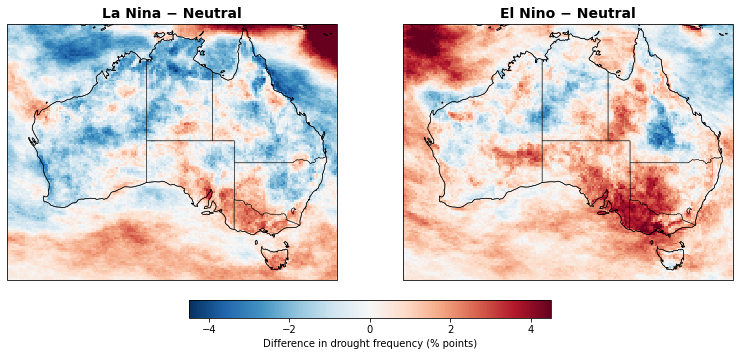

In [17]:
diff_ln = drought_maps["La Nina"] - drought_maps["Neutral"]
diff_en = drought_maps["El Nino"] - drought_maps["Neutral"]

vlim = np.nanpercentile(np.abs(np.stack([diff_ln, diff_en])), 99)

fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                         subplot_kw={"projection": ccrs.PlateCarree()})
for ax, diff, label in zip(axes, [diff_ln, diff_en],
                            ["La Nina − Neutral", "El Nino − Neutral"]):
    base_map(ax)
    pm = ax.pcolormesh(cf_lon_all, cf_lat_all, diff,
                       cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                       transform=ccrs.PlateCarree(), shading="auto")
    ax.set_title(label, fontsize=14, fontweight="bold")
cb = fig.colorbar(pm, ax=axes, orientation="horizontal", shrink=0.5, pad=0.06)
cb.set_label("Difference in drought frequency (% points)")
fig.suptitle(f"Change in wind drought frequency under ENSO, {YEAR_START}-{YEAR_END}",
             fontsize=15, y=1.04)
fig.savefig(os.path.join(OUT_DIR, "drought_freq_difference.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. Seasonal drought frequency in the southeast

Averaged over the SE box, the share of days in drought by ENSO phase and season. This
links ENSO to the winter demand peak, when SE wind droughts matter most for the NEM.

     La Nina  El Nino  Neutral
DJF     14.3     14.7     11.4
MAM     29.7     29.4     28.8
JJA     17.8     19.5     14.9
SON     11.1     14.0     10.7


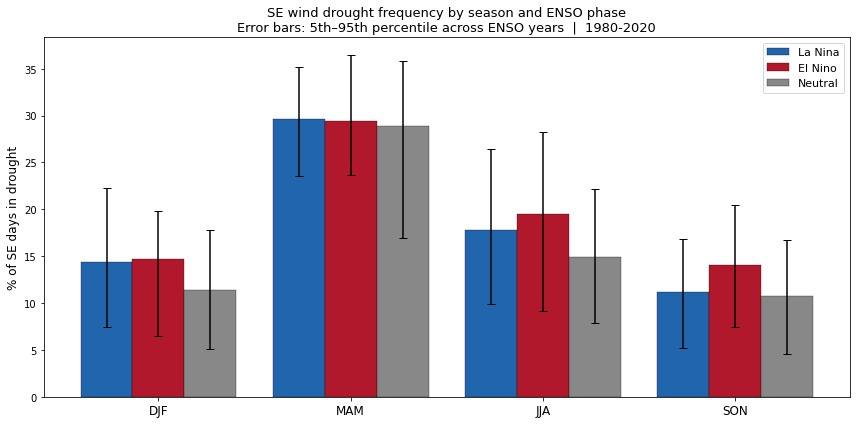

In [18]:
def yearly_drought_pct(phase_years, season_months):
    """
    For each ENSO year in phase_years, compute the % of SE drought days
    in the given season. Returns a list of values (one per year).
    """
    values = []
    for yr in phase_years:
        # Days in this ENSO year (Jun yr → May yr+1)
        in_year = np.array([
            (enso_year_of(ts) == yr) and (ts.month in season_months)
            for ts in time_cf
        ])
        if in_year.sum() == 0:
            continue
        pct = se_drought[in_year].mean() * 100
        values.append(pct)
    return np.array(values)

# Identify neutral ENSO years
all_enso_years = set(range(YEAR_START, YEAR_END + 1))
neutral_years  = sorted(all_enso_years - set(LANINA_YEARS) - set(ELNINO_YEARS))
PHASE_YEARS    = {"La Nina": LANINA_YEARS, "El Nino": ELNINO_YEARS, "Neutral": neutral_years}

# Compute mean + 5-95% CI per phase per season
table_mean  = pd.DataFrame(index=["DJF","MAM","JJA","SON"], columns=PHASES, dtype=float)
table_lo    = pd.DataFrame(index=["DJF","MAM","JJA","SON"], columns=PHASES, dtype=float)
table_hi    = pd.DataFrame(index=["DJF","MAM","JJA","SON"], columns=PHASES, dtype=float)

for ph in PHASES:
    for s, months in SEASONS.items():
        vals = yearly_drought_pct(PHASE_YEARS[ph], months)
        if len(vals) == 0:
            continue
        table_mean.loc[s, ph] = np.mean(vals)
        table_lo.loc[s, ph]   = np.percentile(vals, 5)
        table_hi.loc[s, ph]   = np.percentile(vals, 95)

print(table_mean.round(1))

# Plot
x = np.arange(len(table_mean.index))
w = 0.27
fig, ax = plt.subplots(figsize=(12, 6))

for i, ph in enumerate(PHASES):
    means  = table_mean[ph].values.astype(float)
    lo     = means - table_lo[ph].values.astype(float)
    hi     = table_hi[ph].values.astype(float) - means
    yerr   = np.array([lo, hi])

    ax.bar(x + (i-1)*w, means, w,
           label=ph, color=PHASE_COLORS[ph], edgecolor="k", lw=0.3)
    ax.errorbar(x + (i-1)*w, means, yerr=yerr,
                fmt="none", color="k", capsize=4, lw=1.5)

ax.set_xticks(x)
ax.set_xticklabels(table_mean.index, fontsize=12)
ax.set_ylabel("% of SE days in drought", fontsize=12)
ax.set_title(
    f"SE wind drought frequency by season and ENSO phase\n"
    f"Error bars: 5th–95th percentile across ENSO years  |  {YEAR_START}-{YEAR_END}",
    fontsize=13,
)
ax.legend(fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "se_drought_by_season_phase_ci.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13. Which SWTs drive SE droughts under each phase

Among the SE drought days (SE-mean CF < 0.10), the share contributed by each weather
type, split by ENSO phase. This tells you whether ENSO changes *which* regime is
responsible for the droughts, not just how many there are.

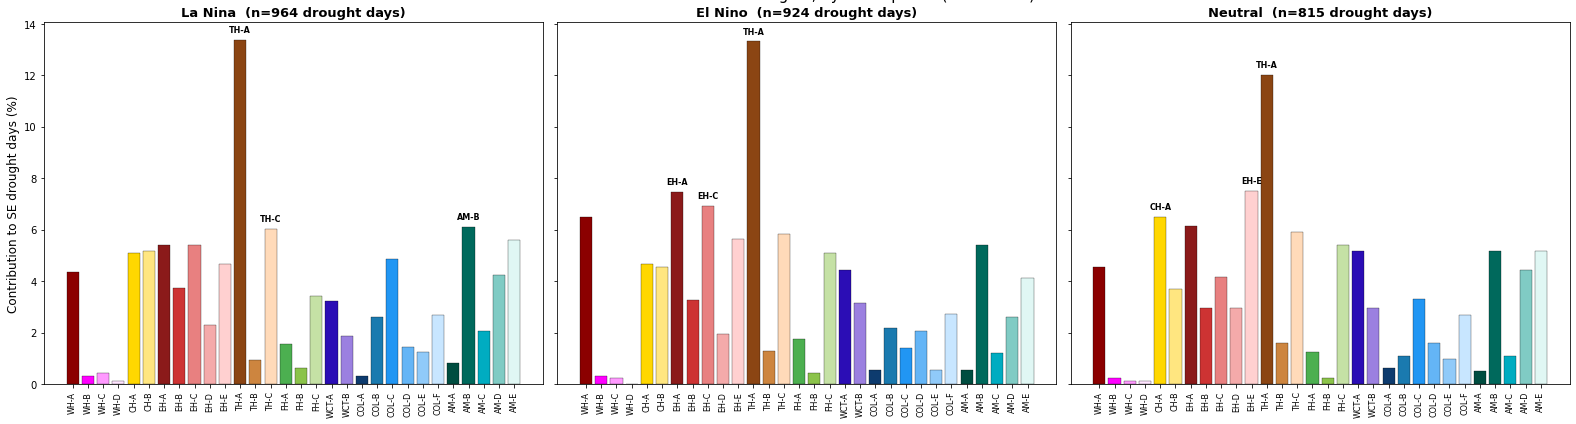

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
for ax, ph in zip(axes, PHASES):
    sel = (phase_cf == ph) & se_drought & (swt_cf != None)
    sub = swt_cf[sel]
    if len(sub) == 0:
        ax.set_title(f"{ph} (no SE drought days)", fontsize=13)
        continue
    contrib = (pd.Series(sub).value_counts() / len(sub) * 100).reindex(SWT_LIST).fillna(0)
    colors = [SWT_COLORS[s] for s in SWT_LIST]
    ax.bar(range(N_SWT), contrib.values, color=colors, edgecolor="k", lw=0.3)
    ax.set_xticks(range(N_SWT))
    ax.set_xticklabels(SWT_LIST, rotation=90, fontsize=8)
    ax.set_title(f"{ph}  (n={len(sub)} drought days)", fontsize=13, fontweight="bold")
    # annotate top 3
    top3 = contrib.nlargest(3).index
    for s in top3:
        ax.text(SWT_LIST.index(s), contrib[s] + 0.3, s, ha="center",
                fontsize=8, fontweight="bold")

axes[0].set_ylabel("Contribution to SE drought days (%)", fontsize=12)
fig.suptitle(f"Which SWTs drive SE wind droughts, by ENSO phase ({YEAR_START}-{YEAR_END})",
             fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "se_drought_swt_contribution_by_phase.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## SWT frequency vs drought contribution — SE Australia

In [42]:
# Rebuild df for the ENSO notebook
# se_drought and phase_cf are already defined above
df = pd.DataFrame({
    "cf_se":   se_ts,
    "drought": se_drought.astype(int),
    "season":  season_of,
    "swt":     [swt_by_date.get(d.date(), None) for d in time_cf],
    "phase":   phase_cf,
}, index=time_cf)

df = df.dropna(subset=["swt"])

print(f"{len(df)} days | {df['drought'].sum()} SE drought days")
print(df.head())

14975 days | 2703 SE drought days
               cf_se  drought season   swt    phase
1980-01-01  0.144045        0    DJF  AM-D  Neutral
1980-01-02  0.109487        0    DJF  AM-D  Neutral
1980-01-03  0.127224        0    DJF  AM-E  Neutral
1980-01-04  0.129417        0    DJF  AM-E  Neutral
1980-01-05  0.117986        0    DJF  AM-C  Neutral


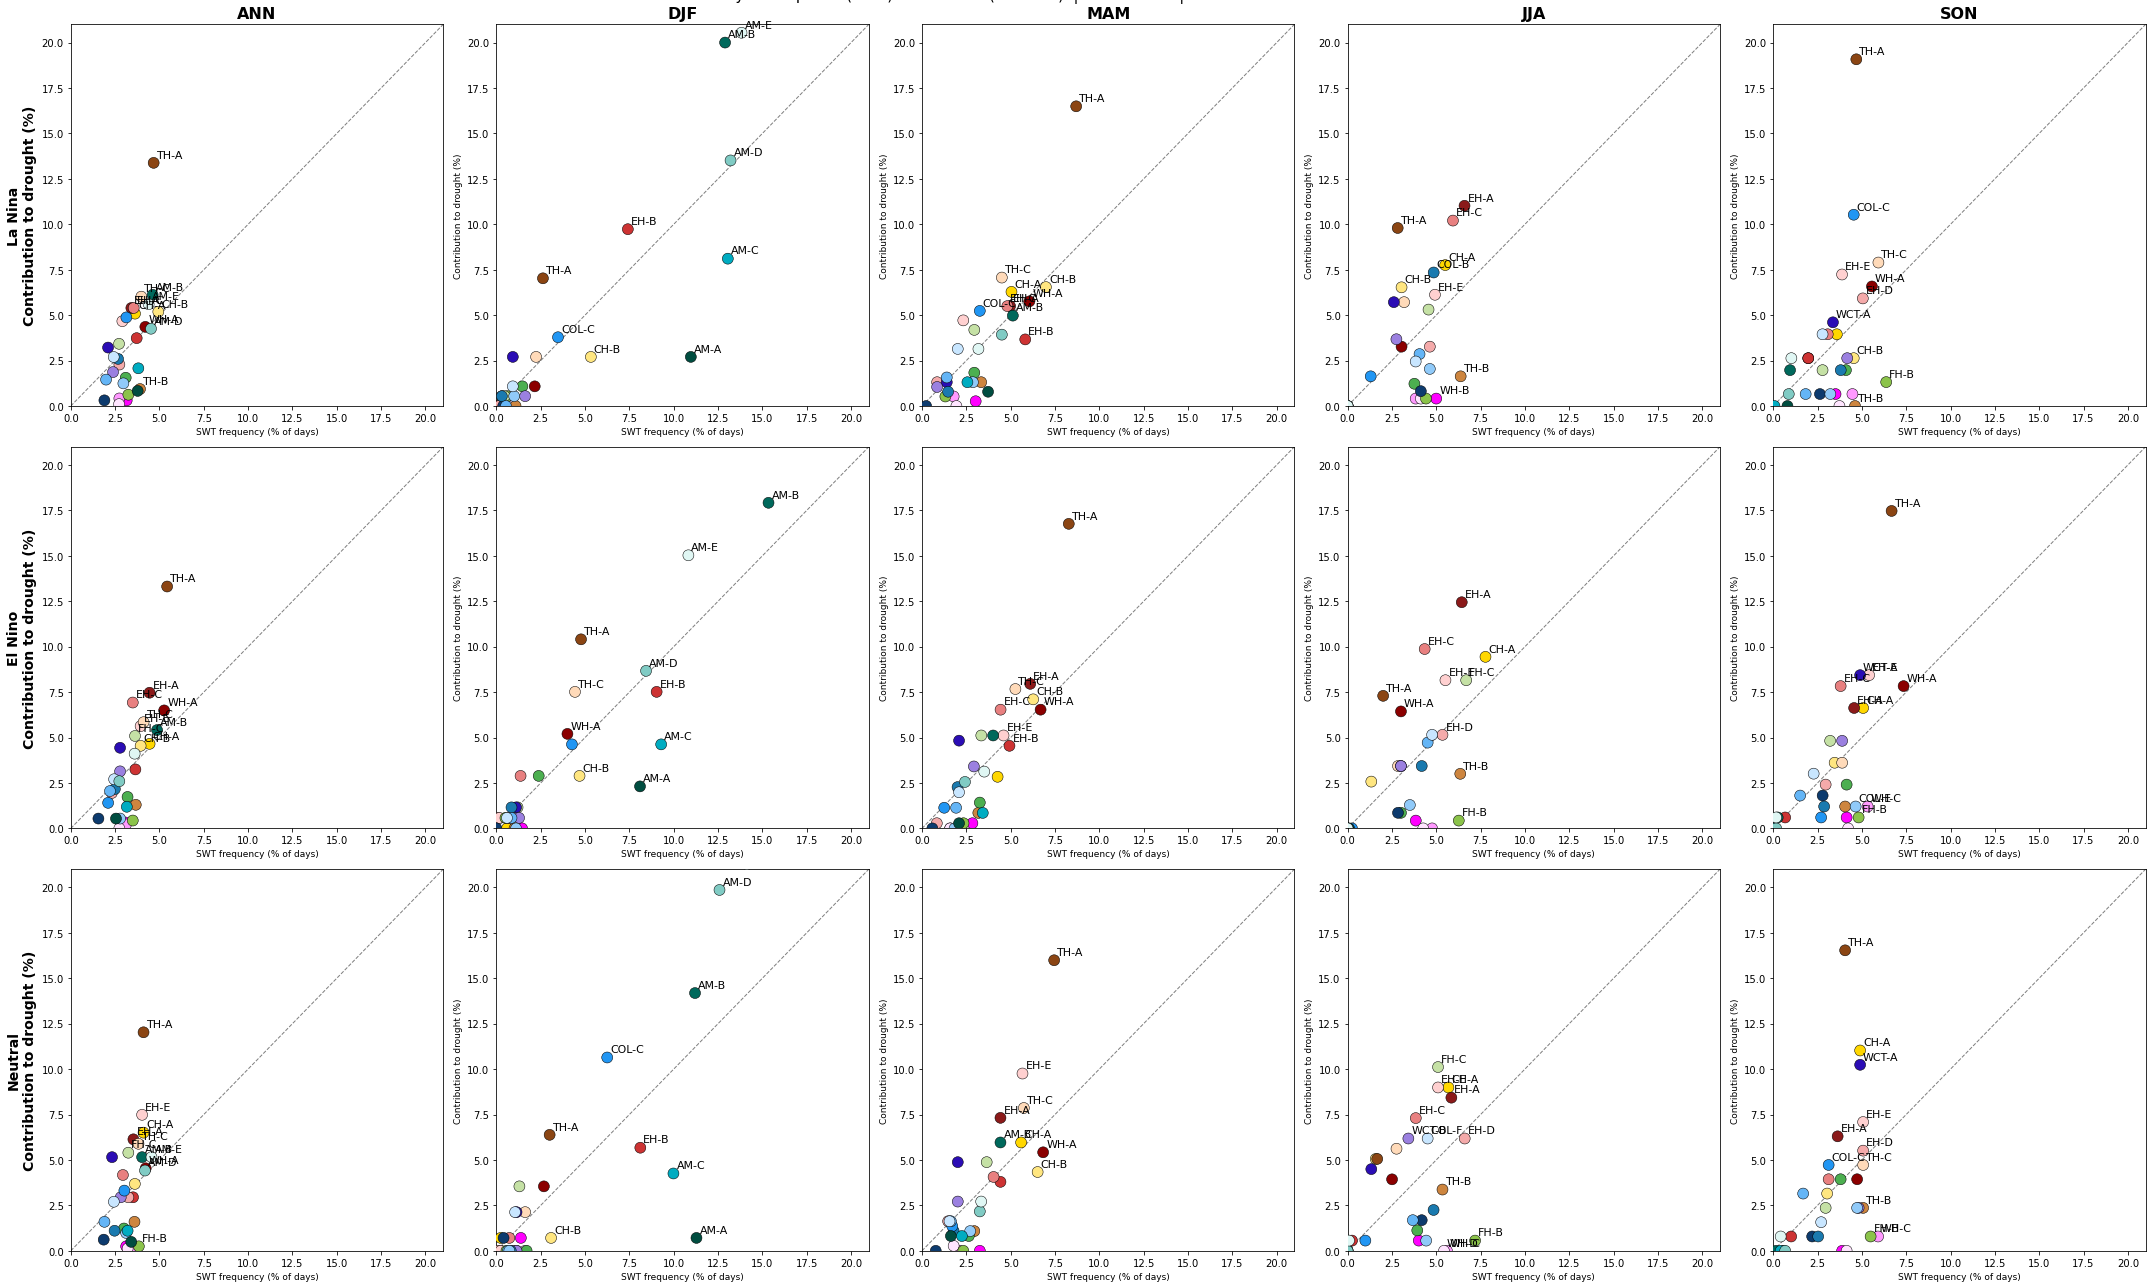

In [46]:
AXIS_MAX = 21
season_keys = ["ANN", "DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(len(PHASES), len(season_keys),
                         figsize=(30, 18))

for row, ph in enumerate(PHASES):
    df_ph = df[df["phase"] == ph].copy()

    for col, key in enumerate(season_keys):
        ax = axes[row, col]

        df_s = df_ph if key == "ANN" else df_ph[df_ph["season"] == key]
        total_days    = len(df_s)
        total_drought = df_s["drought"].sum()

        if total_drought == 0 or total_days == 0:
            ax.set_visible(False)
            continue

        freq    = df_s.groupby("swt").size() / total_days * 100
        contrib = df_s[df_s["drought"] == 1].groupby("swt").size() / total_drought * 100
        pct     = df_s.groupby("swt").apply(lambda g: g["drought"].mean() * 100)

        freq    = freq.reindex(SWT_LIST).fillna(0)
        contrib = contrib.reindex(SWT_LIST).fillna(0)
        pct     = pct.reindex(SWT_LIST).fillna(0)

        colors_swt = [SWT_COLORS[s] for s in SWT_LIST]
        sc = ax.scatter(freq.values, contrib.values,
                        c=colors_swt,
                        s=120, edgecolors="k", lw=0.5, zorder=3)

        ax.plot([0, AXIS_MAX], [0, AXIS_MAX], "k--", lw=1, alpha=0.5)
        ax.set_xlim(0, AXIS_MAX)
        ax.set_ylim(0, AXIS_MAX)

        for swt in SWT_LIST:
            if contrib[swt] > contrib.quantile(0.75) or \
               freq[swt] > freq.quantile(0.75):
                ax.annotate(swt, (freq[swt], contrib[swt]),
                            fontsize=11, ha="left", va="bottom",
                            xytext=(3, 3), textcoords="offset points")

        ax.set_xlabel("SWT frequency (% of days)", fontsize=9)

        if row == 0:
            ax.set_title(key, fontsize=16, fontweight="bold")

        if col == 0:
            ax.set_ylabel(f"{ph}\nContribution to drought (%)",
                          fontsize=14, fontweight="bold")
        else:
            ax.set_ylabel("Contribution to drought (%)", fontsize=9)

fig.suptitle(
    f"SWT frequency vs drought contribution — SE Australia (CF < {CF_THRESHOLD})\n"
    f"By ENSO phase (rows) and season (columns)  |  {YEAR_START}-{YEAR_END}  |  "
    f"Dot colours: Barnes et al. 2025",
    fontsize=15, y=1.02,
)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "swt_freq_vs_drought_enso_seasonal.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 14. Summary statistics

In [14]:
print(f"=== ENSO wind-drought summary, {YEAR_START}-{YEAR_END} ===\n")
for ph in PHASES:
    sel = (phase_cf == ph)
    se_dr = se_drought[sel].mean() * 100
    n_years = len(set(enso_year_of(ts) for ts in time_cf[sel]))
    print(f"{ph:8s}: {sel.sum():5d} days | SE drought {se_dr:4.1f}% of days")

print("\nMost frequent SWT overall, per phase:")
for ph in PHASES:
    sub = swt_cf[(phase_cf == ph) & (swt_cf != None)]
    top = pd.Series(sub).value_counts().head(3)
    print(f"  {ph:8s}: " + ", ".join(f"{k} ({v/len(sub)*100:.0f}%)" for k, v in top.items()))

print("\nTop SWT among SE drought days, per phase:")
for ph in PHASES:
    sub = swt_cf[(phase_cf == ph) & se_drought & (swt_cf != None)]
    if len(sub):
        top = pd.Series(sub).value_counts().head(3)
        print(f"  {ph:8s}: " + ", ".join(f"{k} ({v/len(sub)*100:.0f}%)" for k, v in top.items()))

=== ENSO wind-drought summary, 1980-2020 ===

La Nina :  5329 days | SE drought 18.1% of days
El Nino :  4748 days | SE drought 19.5% of days
Neutral :  4899 days | SE drought 16.6% of days

Most frequent SWT overall, per phase:
  La Nina : CH-B (5%), TH-A (5%), AM-B (5%)
  El Nino : TH-A (5%), WH-A (5%), AM-B (5%)
  Neutral : AM-E (5%), WH-A (4%), AM-D (4%)

Top SWT among SE drought days, per phase:
  La Nina : TH-A (13%), AM-B (6%), TH-C (6%)
  El Nino : TH-A (13%), EH-A (7%), EH-C (7%)
  Neutral : TH-A (12%), EH-E (7%), CH-A (7%)


## 15. Notes, caveats and possible extensions

**How to read these results**

- Section 9 (regime anomalies) is the cleanest ENSO signal: it shows which synoptic types
  ENSO favours, independent of the wind-energy question.
- Section 11 (difference maps) shows where droughts shift. If La Niña reddens the
  southeast, it means more low-wind days there during La Niña years.
- Section 13 tells you whether ENSO changes the *mechanism*: same regime more often, or a
  different regime taking over.

**Caveats**

- Sample sizes differ between phases (15 La Niña vs 13 El Niño years), so Neutral has the
  most days. Frequencies are normalised, but rare regimes will still be noisier under the
  shorter phases.
- No significance test is applied. Before drawing strong conclusions, bootstrap the phase
  labels (resample ENSO years with replacement) to put confidence intervals on the
  difference maps and the SE seasonal table.
- ENSO years here are assigned as whole Jun–May blocks. A finer approach would weight each
  day by the actual ONI/RONI value rather than a binary phase.

**Extensions worth doing**

- Split La Niña and El Niño into strong vs weak events to test amplitude dependence.
- Add the IOD and SAM as co-predictors, since they interact with ENSO over SE Australia.
- Repeat the drought difference maps using the BARRA percentile-based drought definition,
  to check robustness across datasets.
- Compose MSLP / Z500 anomalies for the dominant drought regime under each phase to
  connect the statistics back to the physical circulation.
